In [1]:
#Since we're trying to predict a number, this kind of problem is known as a REGRESSION problem.
#Time Series (or Forecasting) problem: try to predicting results with a time component.

In [2]:
#How well can we predict the future sale price of a bulldozer, given its characteristics previous examples of how much similar bulldozers have been sold for?
#To see how well our model is doing, we'll calculate the RMSLE and then compare our results to others on the Kaggle leaderboard.

In [3]:
#Data Dictionary
#SalesID: unique identifier of a particular sale of a machine at auction. Independent variable
#MachineID	identifier for a particular machine; machines may have multiple sales. Independent variable
#ModelID	identifier for a unique machine model (i.e. fiModelDesc). Independent variable
#datasource	source of the sale record; some sources are more diligent about reporting attributes of the machine than others. Note that a particular datasource may report on multiple auctioneerIDs.	Independent variable
#auctioneerID	identifier of a particular auctioneer, i.e. company that sold the machine at auction. Not the same as datasource.	Independent variable
#YearMade	year of manufacturer of the Machine	Independent variable
#MachineHoursCurrentMeter	current usage of the machine in hours at time of sale (saledate); null or 0 means no hours have been reported for that sale. Independent variable
#UsageBand	value (low, medium, high) calculated comparing this particular Machine-Sale hours to average usage for the fiBaseModel; e.g. 'Low' means this machine has fewer hours given its lifespan relative to the average of fiBaseModel. Independent variable
#Saledate	time of sale. Independent variable
#fiModelDesc	Description of a unique machine model (see ModelID); concatenation of fiBaseModel & fiSecondaryDesc & fiModelSeries & fiModelDescriptor. Independent variable
#State	US State in which sale occurred. Independent variable
#Drive_System	machine configuration; typically describes whether 2 or 4 wheel drive. Independent variable
#Enclosure	machine configuration - does the machine have an enclosed cab or not. Independent variable
#Forks	machine configuration - attachment used for lifting. Independent variable
#Pad_Type	machine configuration - type of treads a crawler machine uses. Independent variable
#Ride_Control	machine configuration - optional feature on loaders to make the ride smoother. Independent variable
#Transmission	machine configuration - describes type of transmission; typically automatic or manual. Independent variable
#...	...	...
#SalePrice	cost of sale in USD. Target/dependent variable

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt  #solo il modulo x i graphs
import matplotlib   #lib completa
import numpy as np
import pandas as pd
import seaborn as sns  #seaborn gets shortened to sns, TK - can seaborn be removed for matplotlib (simpler)?

# Print the versions we're using (as long as your versions are equal or higher than these, the code should work)
print(f"pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"matplotlib version: {matplotlib.__version__}") 

pandas version: 3.0.2
NumPy version: 2.4.3
matplotlib version: 3.10.8


In [5]:
# Timestamp
import datetime
print(f"Notebook last run (end-to-end): {datetime.datetime.now()}")

Notebook last run (end-to-end): 2026-04-17 15:14:02.124140


In [10]:
#now download all datas in https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/data/bluebook-for-bulldozers.zip
#and put them in my notebook under D:\ML_ProjectFolders\ml_scikit-learn_1\data\bluebook-for-bulldozers cioe nel mio notebook ml_scikit-learn_1->folder 'data'->dir 'bluebook-for-bulldozers'

In [8]:
from pathlib import Path
import urllib.request  #x scaricare file da internet
import zipfile
import os

# Check if 'bluebook-for-bulldozers' exists in the current or parent directory
# Link to data (see the file "bluebook-for-bulldozers"): https://github.com/mrdbourke/zero-to-mastery-ml/tree/master/data
dataset_dir = Path("./data/bluebook-for-bulldozers")

if not (dataset_dir.is_dir()):
    print(f"[INFO] Can't find existing 'bluebook-for-bulldozers' dataset in current directory or parent directory, downloading...")
    #Download and unzip the bluebook for bulldozers dataset
    url = "https://github.com/mrdbourke/zero-to-mastery-ml/raw/master/data/bluebook-for-bulldozers.zip"
    filename = "bluebook-for-bulldozers.zip"
    urllib.request.urlretrieve(url, filename)  #scarica file target da quell'url
    with zipfile.ZipFile(filename, 'r') as zip_ref:  #'r' solo in read mode
        zip_ref.extractall("../data")
    # Ensure a data directory exists and move the downloaded dataset there
    # (extractall already places it inside ../data/)
    os.makedirs("../data", exist_ok=True)
    print(f"[INFO] Current dataset dir: {dataset_dir}")
    # Remove .zip file from notebook directory
    os.remove(filename)

else:
    #if the target dataset directory exists, we don't need to download it
    print(f"[INFO] 'bluebook-for-bulldozers' dataset exists, feel free to proceed!")
    print(f"[INFO] Current dataset dir: {dataset_dir}")

[INFO] 'bluebook-for-bulldozers' dataset exists, feel free to proceed!
[INFO] Current dataset dir: data\bluebook-for-bulldozers


In [9]:
#let's check what files are available
import os
print(f"[INFO] Files/folders available in {dataset_dir}:")
os.listdir(dataset_dir)

[INFO] Files/folders available in data\bluebook-for-bulldozers:


['Data Dictionary.xlsx',
 'TrainAndValid.zip',
 'Train.zip',
 'Valid.7z',
 'random_forest_benchmark_test.csv',
 'median_benchmark.csv',
 'ValidSolution.csv',
 'Valid.zip',
 'test_predictions.csv',
 'Test.csv',
 'Valid.csv',
 'TrainAndValid.7z',
 'Train.7z',
 'Machine_Appendix.csv',
 'train_tmp.csv',
 'TrainAndValid.csv']

In [11]:
#info
#The training data (Train.csv) contains sale data from 1989 up to the end of 2011.
#The validation data (Valid.csv) contains sale data from January 1, 2012 - April 30, 2012.
#The test data (Test.csv) contains sale data from May 1, 2012 - November 2012.

In [14]:
# Import the training and validation set
df = pd.read_csv(filepath_or_buffer="../data/bluebook-for-bulldozers/TrainAndValid.csv")

#the red notice is just saying that some of our columns have multiple/mixed data types. For example, a column may contain strings but also contain integers. This is okay for now and can be addressed later on if necessary.

C:\Users\nelvy\AppData\Local\Temp\ipykernel_13900\2693909164.py:2: DtypeWarning: Columns (0: fiModelSeries, 1: Coupler_System, 2: Grouser_Tracks, 3: Hydraulics_Flow) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath_or_buffer="../data/bluebook-for-bulldozers/TrainAndValid.csv")


In [16]:
# Get info about DataFrame
df.info()

#we have over 400,000 entries!
#remember, when the Dtype is object, it's saying that it's a string.

<class 'pandas.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   str    
 9   saledate                  412698 non-null  str    
 10  fiModelDesc               412698 non-null  str    
 11  fiBaseModel               412698 non-null  str    
 12  fiSecondaryDesc           271971 non-null  str    
 13  fiModelSeries             58667 non-null   object 
 14 

In [17]:
df["saledate"][:10]
#we see that column 'saledate' is of type obj, ma in form of dates!
#We are working on TIME SERIES, so worth it to turn these strings into Python datetime objects!

0    11/16/2006 0:00
1     3/26/2004 0:00
2     2/26/2004 0:00
3     5/19/2011 0:00
4     7/23/2009 0:00
5    12/18/2008 0:00
6     8/26/2004 0:00
7    11/17/2005 0:00
8     8/27/2009 0:00
9      8/9/2007 0:00
Name: saledate, dtype: str

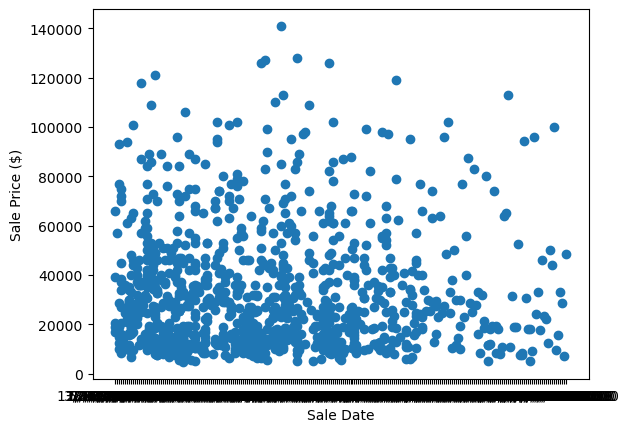

In [18]:
#but before visualize our 'salesdate' columnn vs our 'SalesPrice' column
fig, ax = plt.subplots()
ax.scatter(x=df["saledate"][:1000], # visualize the first 1000 values
           y=df["SalePrice"][:1000])
ax.set_xlabel("Sale Date")
ax.set_ylabel("Sale Price ($)");

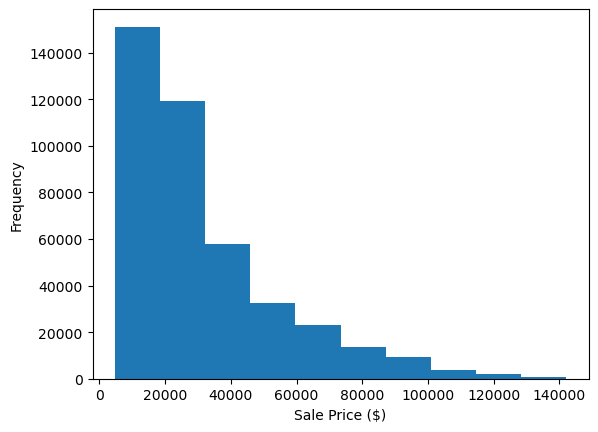

In [19]:
# View SalePrice distribution, bc 'SalePrice' is aready in format float64
df.SalePrice.plot.hist(xlabel="Sale Price ($)");

In [21]:
#We tell pandas which columns(we want column 'saledate') to read in as dates by setting the parse_dates parameter in pd.read_csv

df = pd.read_csv(filepath_or_buffer="../data/bluebook-for-bulldozers/TrainAndValid.csv",
                 low_memory=False,  #set low_memory=False to prevent mixed data types warning 
                 parse_dates=["saledate"])  #can use the parse_dates parameter and specify which column to treat as a date column

# With parse_dates... check dtype of "saledate"
df.info()

#nice! Now our 'saledate' column is of type datetime64[ns]: a NumPy-specific datetime format with high precision!

<class 'pandas.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   SalesID                   412698 non-null  int64         
 1   SalePrice                 412698 non-null  float64       
 2   MachineID                 412698 non-null  int64         
 3   ModelID                   412698 non-null  int64         
 4   datasource                412698 non-null  int64         
 5   auctioneerID              392562 non-null  float64       
 6   YearMade                  412698 non-null  int64         
 7   MachineHoursCurrentMeter  147504 non-null  float64       
 8   UsageBand                 73670 non-null   str           
 9   saledate                  412698 non-null  datetime64[us]
 10  fiModelDesc               412698 non-null  str           
 11  fiBaseModel               412698 non-null  str           
 12  fiSecondaryDe

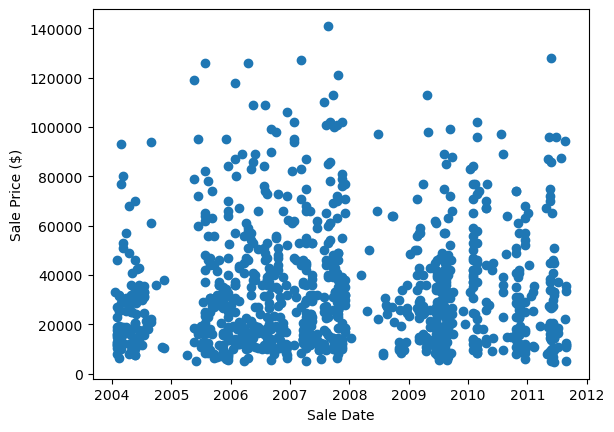

In [22]:
#re-visualize our 'salesdate' columnn vs our 'SalesPrice' column

fig, ax = plt.subplots()
ax.scatter(x=df["saledate"][:1000],   #visualize the first 1000 values
           y=df["SalePrice"][:1000])
ax.set_xlabel("Sale Date")
ax.set_ylabel("Sale Price ($)");

In [23]:
#Sorting our DataFrame by saledate

# Sort DataFrame in date order
df.sort_values(by=["saledate"], inplace=True, ascending=True)
df.saledate.head(10), df.saledate.tail(10)

(205615   1989-01-17
 274835   1989-01-31
 141296   1989-01-31
 212552   1989-01-31
 62755    1989-01-31
 54653    1989-01-31
 81383    1989-01-31
 204924   1989-01-31
 135376   1989-01-31
 113390   1989-01-31
 Name: saledate, dtype: datetime64[us],
 409202   2012-04-28
 408976   2012-04-28
 411695   2012-04-28
 411319   2012-04-28
 408889   2012-04-28
 410879   2012-04-28
 412476   2012-04-28
 411927   2012-04-28
 407124   2012-04-28
 409203   2012-04-28
 Name: saledate, dtype: datetime64[us])

In [24]:
#Adding extra features to our DataFrame
#Feature eengineering:  taking existing features and using them to create more/different features.
#we'll use our saledate column to add extra features such as: Year of sale, Month of sale, Day of sale, Day of week sale (e.g. Monday = 1, Tuesday = 2)
    #, Day of year sale (e.g. January 1st = 1, January 2nd = 2)

In [25]:
#Since we're going to be manipulating the data, we'll make a CLONE of the original DataFrame and perform our changes there.

# Make a copy of the original DataFrame to perform edits on
df_tmp = df.copy()  #clone

In [26]:
# Add datetime parameters for saledate
df_tmp["saleYear"] = df_tmp.saledate.dt.year
df_tmp["saleMonth"] = df_tmp.saledate.dt.month
df_tmp["saleDay"] = df_tmp.saledate.dt.day
df_tmp["saleDayofweek"] = df_tmp.saledate.dt.dayofweek
df_tmp["saleDayofyear"] = df_tmp.saledate.dt.dayofyear

# Drop original saledate column
df_tmp.drop("saledate", axis=1, inplace=True)

In [27]:
# View newly created columns
df_tmp[["SalePrice", "saleYear", "saleMonth", "saleDay", "saleDayofweek", "saleDayofyear"]].head()

,SalePrice,saleYear,saleMonth,saleDay,saleDayofweek,saleDayofyear
205615,9500.0,1989,1,17,1,17
274835,14000.0,1989,1,31,1,31
141296,50000.0,1989,1,31,1,31
212552,16000.0,1989,1,31,1,31
62755,22000.0,1989,1,31,1,31


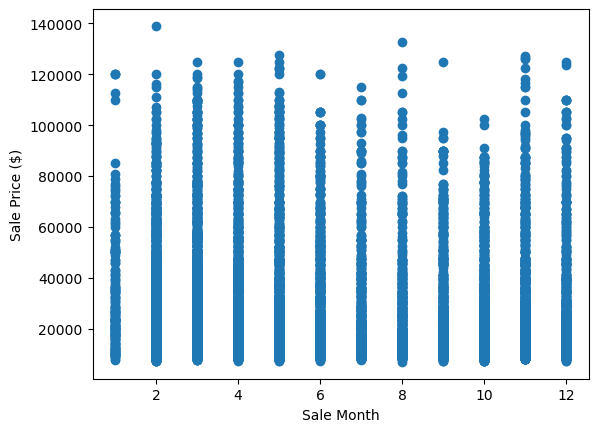

In [28]:
#now we view the first 10,000 samples (we could also randomly select 10,000 samples too) to see if reveals anything about which month has the highest sales

# View 10,000 samples SalePrice against saleMonth
fig, ax = plt.subplots()
ax.scatter(x=df_tmp["saleMonth"][:10000], y=df_tmp["SalePrice"][:10000])  #see the first 10k values
ax.set_xlabel("Sale Month")
ax.set_ylabel("Sale Price ($)");

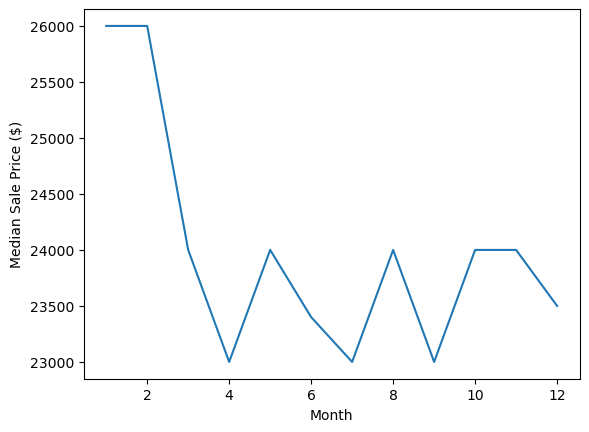

In [29]:
#How about we plot the median sale price of each month?

# Group DataFrame by saleMonth and then find the median SalePrice
df_tmp.groupby(["saleMonth"])["SalePrice"].median().plot()
plt.xlabel("Month")
plt.ylabel("Median Sale Price ($)");

In [30]:
#Inspect values of other columns


In [ ]:
#Modeling

# This won't work since we've got missing numbers and categories
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_jobs=-1)
model.fit(df_tmp.drop("SalePrice", axis=1), df_tmp.SalePrice)

# Check for missing categories and different datatypes
df_tmp.info()

# Check for missing values
df_tmp.isna().sum()

df_tmp.head().T

In [ ]:
pd.api.types.is_string_dtype(df_tmp["UsageBand"])

In [ ]:
# These columns contain strings
for label, content in df_tmp.items():
    if pd.api.types.is_string_dtype(content):
        print(label)

In [ ]:
# If you're wondering what df.items() does, let's use a dictionary as an example
random_dict = {"key1": "hello",
               "key2": "world!"}

for key, value in random_dict.items():
    print(f"This is a key: {key}")
    print(f"This is a value: {value}")

In [ ]:
#This will turn all of the string values into category values
for label, content in df_tmp.items():
    if pd.api.types.is_string_dtype(content):
        df_tmp[label] = content.astype("category").cat.as_ordered()

In [ ]:
df_tmp.info()

df_tmp.state.cat.categories

df_tmp.state.cat.codes
df_tmp.isnull().sum()/len(df_tmp)

In [ ]:
#SAVE PROCESSED DATA

# Save preprocessed data
df_tmp.to_csv("../data/bluebook-for-bulldozers/train_tmp.csv",
              index=False)

# Import preprocessed data
df_tmp = pd.read_csv("../data/bluebook-for-bulldozers/train_tmp.csv",
                     low_memory=False)
df_tmp.head().T

# Check missing values
df_tmp.isna().sum()

In [ ]:
#FILLING MISSING VALUES

for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        print(label)

# Check for which numeric columns have null values
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(label)

# Fill numeric rows with the median
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            # Add a binary column which tells if the data was missing our not
            df_tmp[label+"_is_missing"] = pd.isnull(content)
            # Fill missing numeric values with median since it's more robust than the mean
            df_tmp[label] = content.fillna(content.median())

# Check if there's any null values
for label, content in df_tmp.items():
    if pd.api.types.is_numeric_dtype(content):
        if pd.isnull(content).sum():
            print(label)

# Check to see how many examples were missing
df_tmp.auctioneerID_is_missing.value_counts()



In [ ]:
#Filling and turning categorical variables to numbers

# Check columns which *aren't* numeric
for label, content in df_tmp.items():
    if not pd.api.types.is_numeric_dtype(content):
        print(label)

# Turn categorical variables into numbers
for label, content in df_tmp.items():
    # Check columns which *aren't* numeric
    if not pd.api.types.is_numeric_dtype(content):
        # Add binary column to inidicate whether sample had missing value
        df_tmp[label+"_is_missing"] = pd.isnull(content)
        # We add the +1 because pandas encodes missing categories as -1
        df_tmp[label] = pd.Categorical(content).codes+1    

df_tmp.info()
df_tmp.isna().sum()
df_tmp.head().T

%%time
# Instantiate model
model = RandomForestRegressor(n_jobs=-1)
# Fit the model
model.fit(df_tmp.drop("SalePrice", axis=1), df_tmp.SalePrice)

# Score the model
model.score(df_tmp.drop("SalePrice", axis=1), df_tmp.SalePrice)

In [ ]:
#Splitting data into train/valid sets
df_tmp.head()
df_tmp.saleYear.value_counts()

# Split data into training and validation
df_val = df_tmp[df_tmp.saleYear == 2012]
df_train = df_tmp[df_tmp.saleYear != 2012]
len(df_val), len(df_train)

# Split data into X & y
X_train, y_train = df_train.drop("SalePrice", axis=1), df_train.SalePrice
X_valid, y_valid = df_val.drop("SalePrice", axis=1), df_val.SalePrice
X_train.shape, y_train.shape, X_valid.shape, y_valid.shape




In [ ]:
#Building an evaluation function
# Create evaluation function (the competition uses Root Mean Square Log Error)
from sklearn.metrics import mean_squared_log_error, mean_absolute_error

def rmsle(y_test, y_preds):
    return np.sqrt(mean_squared_log_error(y_test, y_preds))

# Create function to evaluate our model
def show_scores(model):
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_valid)
    scores = {"Training MAE": mean_absolute_error(y_train, train_preds),
              "Valid MAE": mean_absolute_error(y_valid, val_preds),
              "Training RMSLE": rmsle(y_train, train_preds),
              "Valid RMSLE": rmsle(y_valid, val_preds),
              "Training R^2": model.score(X_train, y_train),
              "Valid R^2": model.score(X_valid, y_valid)}
    return scores



In [ ]:
#Testing our model on a subset (to tune the hyperparameters)
# This takes too long...
# %%time
# # Retrain a model on training data
# model.fit(X_train, y_train)
# show_scores(model)
len(X_train)

# Change max samples in RandomForestRegressor
model = RandomForestRegressor(n_jobs=-1,
                              max_samples=10000)

%%time
# Cutting down the max number of samples each tree can see improves training time
model.fit(X_train, y_train)

show_scores(model)



In [ ]:
#Hyperparameter tuning with RandomizedSearchCV
%%time
from sklearn.model_selection import RandomizedSearchCV

# Different RandomForestClassifier hyperparameters
rf_grid = {"n_estimators": np.arange(10, 100, 10),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(2, 20, 2),
           "min_samples_leaf": np.arange(1, 20, 2),
           "max_features": [0.5, 1, "sqrt", "auto"],
           "max_samples": [10000]}

rs_model = RandomizedSearchCV(RandomForestRegressor(),
                              param_distributions=rf_grid,
                              n_iter=20,
                              cv=5,
                              verbose=True)

rs_model.fit(X_train, y_train)

# Find the best parameters from the RandomizedSearch 
rs_model.best_params_
# Evaluate the RandomizedSearch model
show_scores(rs_model)

In [ ]:
#Train a model with the best parameters
%%time
# Most ideal hyperparameters
ideal_model = RandomForestRegressor(n_estimators=90,
                                    min_samples_leaf=1,
                                    min_samples_split=14,
                                    max_features=0.5,
                                    n_jobs=-1,
                                    max_samples=None)
ideal_model.fit(X_train, y_train)

show_scores(ideal_model)

%%time
# Faster model
fast_model = RandomForestRegressor(n_estimators=40,
                                   min_samples_leaf=3,
                                   max_features=0.5,
                                   n_jobs=-1)
fast_model.fit(X_train, y_train)

show_scores(fast_model)

In [ ]:
#Make predictions on test data

df_test = pd.read_csv("../data/bluebook-for-bulldozers/Test.csv",
                      parse_dates=["saledate"])
df_test.head()

# Let's see how the model goes predicting on the test data
model.predict(df_test)

In [ ]:
#Preprocessing the data
def preprocess_data(df):
    # Add datetime parameters for saledate
    df["saleYear"] = df.saledate.dt.year
    df["saleMonth"] = df.saledate.dt.month
    df["saleDay"] = df.saledate.dt.day
    df["saleDayofweek"] = df.saledate.dt.dayofweek
    df["saleDayofyear"] = df.saledate.dt.dayofyear

    # Drop original saledate
    df.drop("saledate", axis=1, inplace=True)
    
    # Fill numeric rows with the median
    for label, content in df.items():
        if pd.api.types.is_numeric_dtype(content):
            if pd.isnull(content).sum():
                df[label+"_is_missing"] = pd.isnull(content)
                df[label] = content.fillna(content.median())
                
        # Turn categorical variables into numbers
        if not pd.api.types.is_numeric_dtype(content):
            df[label+"_is_missing"] = pd.isnull(content)
            # We add the +1 because pandas encodes missing categories as -1
            df[label] = pd.Categorical(content).codes+1        
    
    return df

df_test = preprocess_data(df_test)
df_test.head()
X_train.head()
# Make predictions on the test dataset using the best model
test_preds = ideal_model.predict(df_test)
# We can find how the columns differ using sets
set(X_train.columns) - set(df_test.columns)
# Match test dataset columns to training dataset
df_test["auctioneerID_is_missing"] = False
df_test.head()
# Make predictions on the test dataset using the best model
test_preds = ideal_model.predict(df_test)

# Create DataFrame compatible with Kaggle submission requirements
df_preds = pd.DataFrame()
df_preds["SalesID"] = df_test["SalesID"]
df_preds["SalePrice"] = test_preds
df_preds
# Export to csv...
#df_preds.to_csv("../data/bluebook-for-bulldozers/predictions.csv",
#                index=False)

In [ ]:
#Feature Importance: seeks to figure out which different attributes of the data were most important when it comes to predicting the target variable
# Find feature importance of our best model
ideal_model.feature_importances_

# Install Seaborn package in current environment (if you don't have it)
# import sys
# !conda install --yes --prefix {sys.prefix} seaborn


import seaborn as sns
# Helper function for plotting feature importance
def plot_features(columns, importances, n=20):
    df = (pd.DataFrame({"features": columns,
                        "feature_importance": importances})
          .sort_values("feature_importance", ascending=False)
          .reset_index(drop=True))
    
    sns.barplot(x="feature_importance",
                y="features",
                data=df[:n],
                orient="h")

plot_features(X_train.columns, ideal_model.feature_importances_)
sum(ideal_model.feature_importances_)
df.ProductSize.isna().sum()
df.ProductSize.value_counts()
df.Turbocharged.value_counts()
df.Thumb.value_counts()